In [ ]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
import pandas as pd
#base learners
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression, PassiveAggressiveClassifier, RidgeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.ensemble import GradientBoostingClassifier

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

data = pd.read_csv(r'/content/drive/MyDrive/smart grid stability/Data_for_UCI_named.csv')

Mounted at /content/drive


In [ ]:
map1 = {'unstable': 0, 'stable': 1}
data['stabf'] = data['stabf'].replace(map1)

data = data.sample(frac=1)
X = data.iloc[:, :12]
y = data.iloc[:, 13]


/tmp/ipython-input-2108443977.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data['stabf'] = data['stabf'].replace(map1)


In [ ]:
y.head()

,stabf
579,0
2016,0
6211,0
8776,0
1407,0


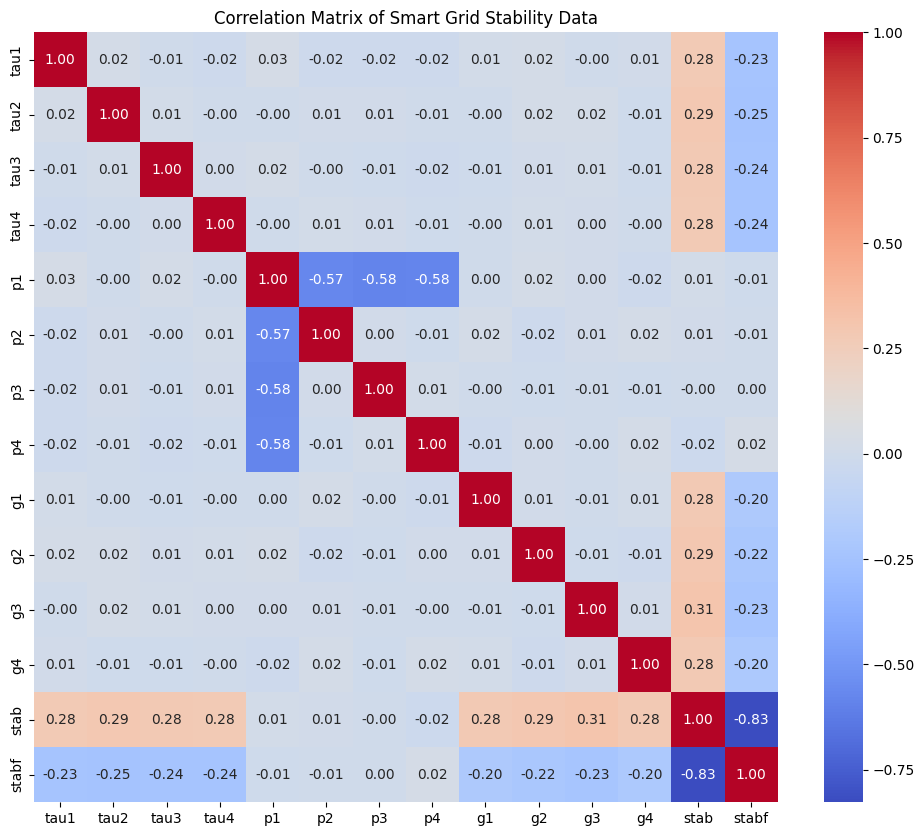

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate the correlation matrix
correlation_matrix = data.corr(numeric_only=True)

# Plot the heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Smart Grid Stability Data')
plt.show()


In [ ]:
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, precision_score, recall_score
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=60)

base_learners = [
    ('dt', DecisionTreeClassifier(criterion='entropy', max_depth=None)),
    ('rf', RandomForestClassifier(max_depth= None, min_samples_split = 5, n_estimators =30)),
    ('svc', SVC(probability=True, C= 10, kernel= 'rbf')),
    ('nb', GaussianNB()),
    ('gb', GradientBoostingClassifier(learning_rate=0.01, max_depth= 7, n_estimators=150)),
    ('xgb', XGBClassifier()),
    ('lr', LogisticRegression(C = 1)),
    ('knn', KNeighborsClassifier(n_neighbors= 7, weights='distance')),
    # ('ada', AdaBoostClassifier(learning_rate=0.01,n_estimators=150)),
    ('qda', QuadraticDiscriminantAnalysis(reg_param=0.3)),
    # ('pa', PassiveAggressiveClassifier(max_iter=1000,C=0.01, random_state=0, tol=1e-3)),
    ('ridge', RidgeClassifier(alpha= 0.1))
]


from sklearn.ensemble import RandomForestClassifier
meta_learner = RandomForestClassifier()


# stacking classifier
stacking_clf = StackingClassifier(
    estimators=base_learners,
    final_estimator=meta_learner
)

stacking_clf.fit(X_train, y_train)
score = stacking_clf.score(X_test, y_test)
print("Stacking Classifier Accuracy:", score)

Stacking Classifier Accuracy: 0.9575


Stacking Classifier Accuracy: 0.9911666666666666

In [ ]:
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, precision_score, recall_score

# Make predictions on the test set
y_pred = stacking_clf.predict(X_test)

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

# Print the metrics
print(f"Accuracy: {accuracy:.4f}")
print(f"F1-score: {f1:.4f}")
print(f"ROC AUC: {roc_auc:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")

Accuracy: 0.9575
F1-score: 0.9420
ROC AUC: 0.9538
Precision: 0.9439
Recall: 0.9401


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

metrics_data = []

for name, clf in base_learners:
    # Fit the base learner
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    metrics_data.append({'Classifier': name, 'Metric': 'Accuracy', 'Score': accuracy})
    metrics_data.append({'Classifier': name, 'Metric': 'F1-score', 'Score': f1})
    metrics_data.append({'Classifier': name, 'Metric': 'ROC AUC', 'Score': roc_auc})
    metrics_data.append({'Classifier': name, 'Metric': 'Precision', 'Score': precision})
    metrics_data.append({'Classifier': name, 'Metric': 'Recall', 'Score': recall})
print("Done collecting base learner metrics.")

print("Collecting metrics for stacking classifier...")
y_pred_stacking = stacking_clf.predict(X_test)
accuracy_stacking = accuracy_score(y_test, y_pred_stacking)
f1_stacking = f1_score(y_test, y_pred_stacking)
roc_auc_stacking = roc_auc_score(y_test, y_pred_stacking)
precision_stacking = precision_score(y_test, y_pred_stacking)
recall_stacking = recall_score(y_test, y_pred_stacking)
metrics_data.append({'Classifier': 'Stacking', 'Metric': 'Accuracy', 'Score': accuracy_stacking})
metrics_data.append({'Classifier': 'Stacking', 'Metric': 'F1-score', 'Score': f1_stacking})
metrics_data.append({'Classifier': 'Stacking', 'Metric': 'ROC AUC', 'Score': roc_auc_stacking})
metrics_data.append({'Classifier': 'Stacking', 'Metric': 'Precision', 'Score': precision_stacking})
metrics_data.append({'Classifier': 'Stacking', 'Metric': 'Recall', 'Score': recall_stacking})
print("Done collecting stacking classifier metrics.")

metrics_df = pd.DataFrame(metrics_data)

display(metrics_df.head())

Done collecting base learner metrics.
Done collecting stacking classifier metrics.


,Classifier,Metric,Score
0,dt,Accuracy,0.853000
1,dt,F1-score,0.798630
2,dt,ROC AUC,0.840662
3,dt,Precision,0.803030
4,dt,Recall,0.794278


In [ ]:

metrics_table = metrics_df.pivot(index='Metric', columns='Classifier', values='Score')

display(metrics_table)

Classifier,Stacking,dt,gb,knn,lr,nb,qda,rf,ridge,svc,xgb
Metric,,,,,,,,,,,
Accuracy,0.957500,0.853000,0.885000,0.781500,0.804000,0.824500,0.774000,0.898500,0.803500,0.939500,0.943500
F1-score,0.941980,0.798630,0.831378,0.680789,0.723554,0.734292,0.708387,0.855926,0.721868,0.916379,0.921364
Precision,0.943912,0.803030,0.900000,0.733858,0.750000,0.826235,0.672794,0.893333,0.751105,0.929874,0.941679
ROC AUC,0.953835,0.840662,0.861358,0.750693,0.781919,0.790097,0.768528,0.882327,0.780666,0.931888,0.934761
Recall,0.940054,0.794278,0.772480,0.634877,0.698910,0.660763,0.747956,0.821526,0.694823,0.903270,0.901907


/tmp/ipython-input-2945089276.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sorted_metrics.index, y=sorted_metrics.values, palette='viridis')


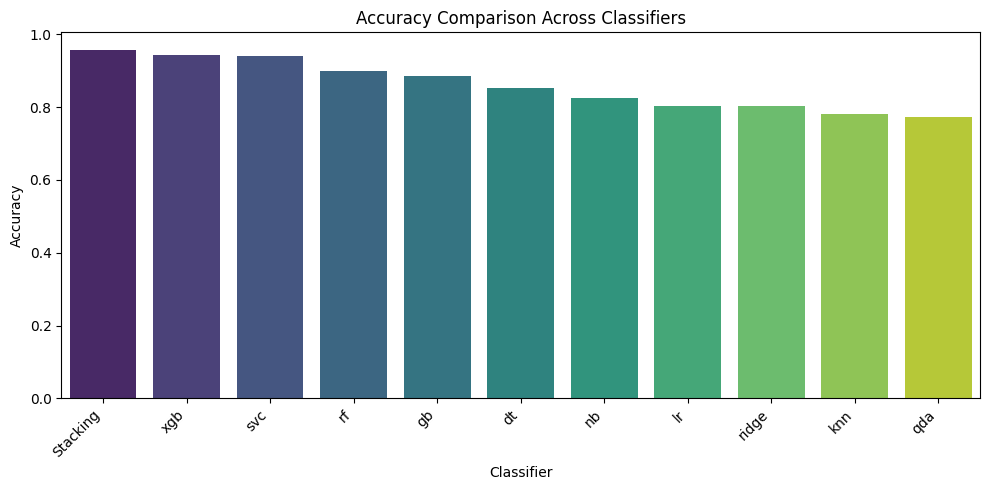

/tmp/ipython-input-2945089276.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sorted_metrics.index, y=sorted_metrics.values, palette='viridis')


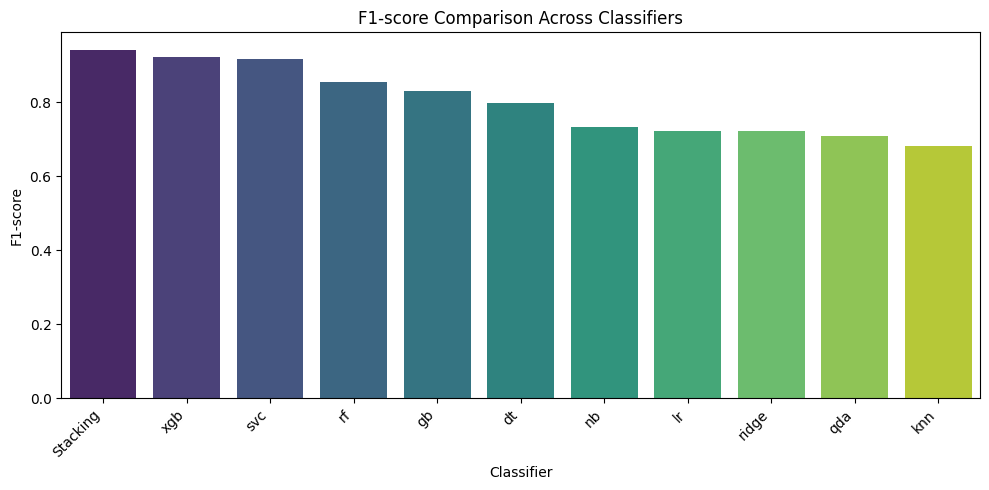

/tmp/ipython-input-2945089276.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sorted_metrics.index, y=sorted_metrics.values, palette='viridis')


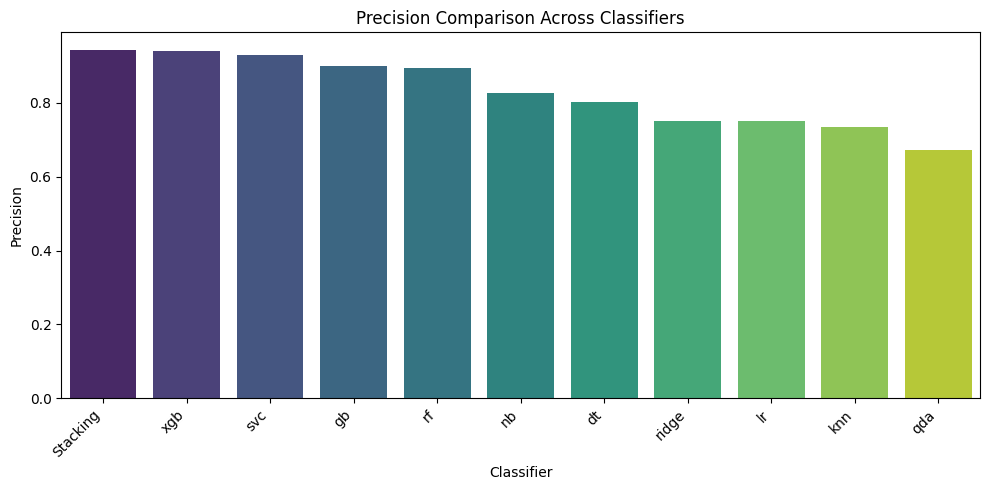

/tmp/ipython-input-2945089276.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sorted_metrics.index, y=sorted_metrics.values, palette='viridis')


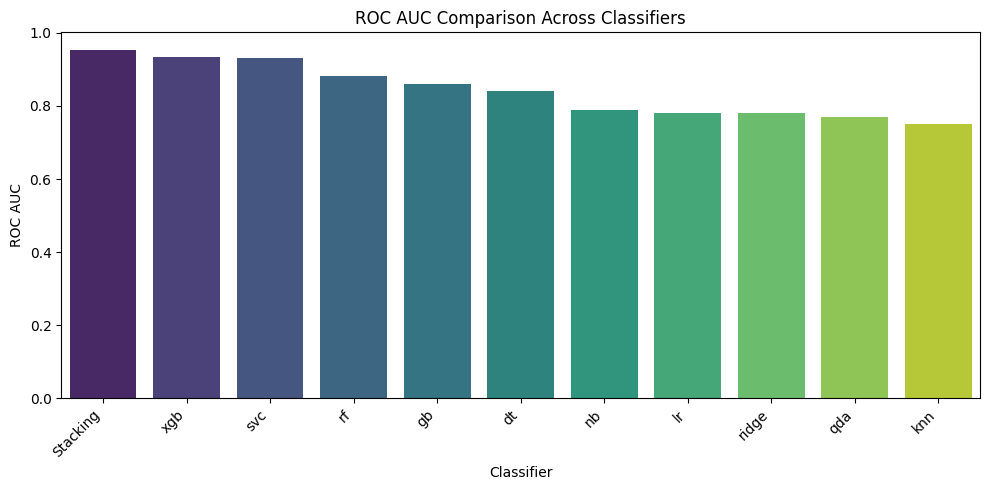

/tmp/ipython-input-2945089276.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sorted_metrics.index, y=sorted_metrics.values, palette='viridis')


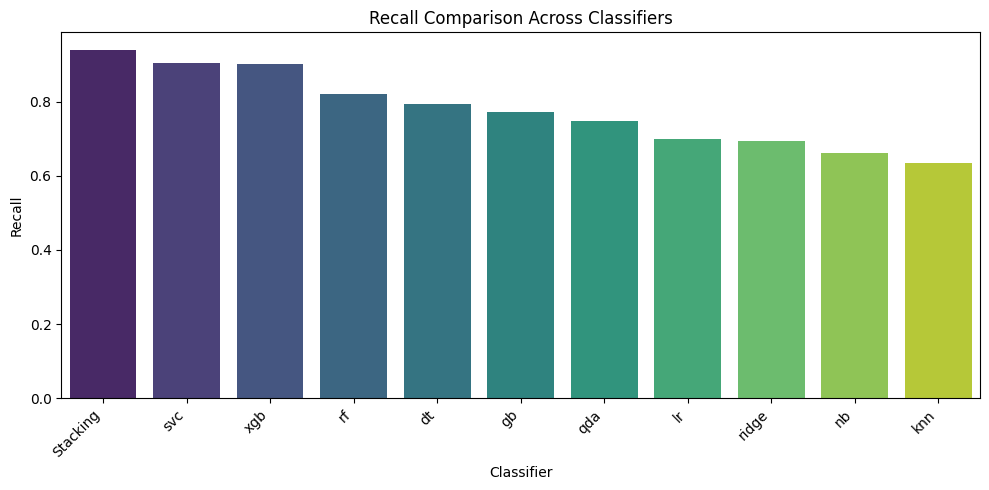

In [ ]:
# Get the list of metrics
metrics = metrics_table.index

# Plotting each metric
for metric in metrics:
    plt.figure(figsize=(10, 5))
    # Sort by metric score for better visualization
    sorted_metrics = metrics_table.loc[metric].sort_values(ascending=False)
    sns.barplot(x=sorted_metrics.index, y=sorted_metrics.values, palette='viridis')
    plt.title(f'{metric} Comparison Across Classifiers')
    plt.ylabel(metric)
    plt.xlabel('Classifier')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

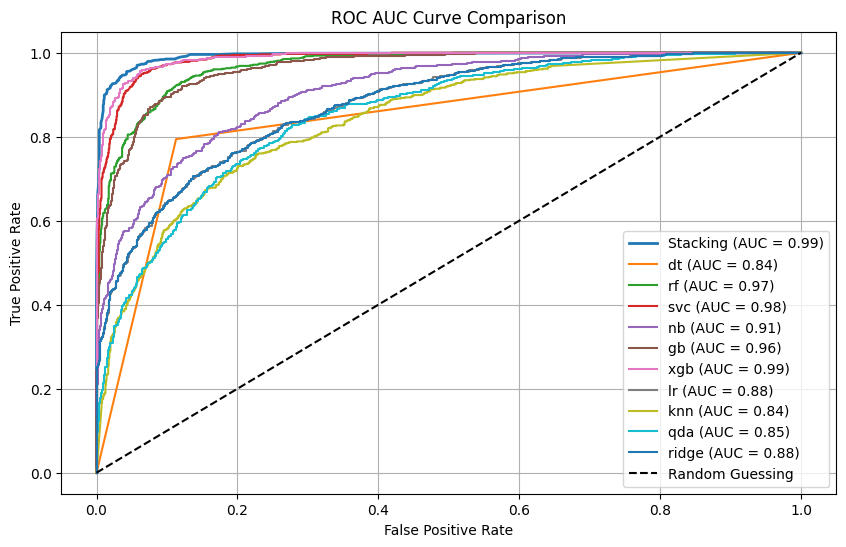

In [ ]:
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(10, 6))

y_pred_proba_stacking = stacking_clf.predict_proba(X_test)[:, 1]
fpr_stacking, tpr_stacking, _ = roc_curve(y_test, y_pred_proba_stacking)
roc_auc_stacking = auc(fpr_stacking, tpr_stacking)
plt.plot(fpr_stacking, tpr_stacking, label=f'Stacking (AUC = {roc_auc_stacking:.2f})', linewidth=2)

for name, clf in base_learners:
    if hasattr(clf, "predict_proba"):
        y_pred_proba = clf.predict_proba(X_test)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.2f})')
    elif hasattr(clf, "decision_function"):
        y_score = clf.decision_function(X_test)
        fpr, tpr, _ = roc_curve(y_test, y_score)
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.2f})')


plt.plot([0, 1], [0, 1], 'k--', label='Random Guessing')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC AUC Curve Comparison')
plt.legend()
plt.grid(True)
plt.show()

You can download the metrics table as a Word document [here](metrics_table.docx).

/tmp/ipython-input-2515928411.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Metric', y='Score', data=stacking_metrics_subset, palette='viridis')


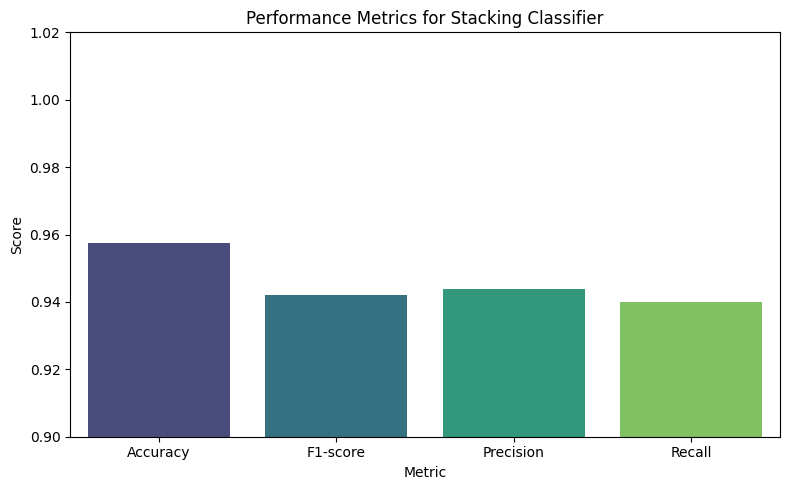

In [ ]:

stacking_metrics = metrics_df[metrics_df['Classifier'] == 'Stacking']
stacking_metrics_subset = stacking_metrics[stacking_metrics['Metric'].isin(['Accuracy', 'F1-score', 'Recall', 'Precision'])]
plt.figure(figsize=(8, 5))
sns.barplot(x='Metric', y='Score', data=stacking_metrics_subset, palette='viridis')
plt.title('Performance Metrics for Stacking Classifier')
plt.ylabel('Score')
plt.xlabel('Metric')
plt.ylim(0.90, 1.02)
plt.tight_layout()
plt.show()

In [ ]:
data


,tau1,tau2,tau3,tau4,p1,p2,p3,p4,g1,g2,g3,g4,stab,stabf
579,0.824967,4.981641,9.970129,9.303904,4.380373,-1.360776,-1.967308,-1.052289,0.563025,0.960425,0.746095,0.076027,0.007118,0
2016,3.752613,4.962008,5.790120,5.992565,4.531827,-1.196636,-1.535881,-1.799310,0.561841,0.654703,0.530708,0.505691,0.059081,0
6211,6.383026,8.549829,9.544005,8.396103,3.255371,-0.690807,-1.110457,-1.454107,0.437732,0.953224,0.253930,0.195620,0.050026,0
8776,8.248449,7.949246,7.882887,1.486206,3.582939,-1.746806,-0.577627,-1.258507,0.996646,0.726733,0.284038,0.751665,0.047319,0
1407,1.258163,0.550799,7.599561,7.466210,4.349765,-0.795026,-1.745326,-1.809413,0.869923,0.283106,0.986958,0.895217,0.026628,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
702,2.452980,6.950304,3.735914,3.767247,4.980448,-1.911726,-1.725024,-1.343697,0.581770,0.841622,0.297482,0.303087,0.016918,0
6546,7.737613,6.184458,1.185741,4.104759,3.771499,-1.449209,-1.648210,-0.674080,0.308478,0.208906,0.147109,0.197675,-0.041641,1
9520,9.155653,2.407185,8.567106,3.105892,4.751044,-1.387220,-1.497929,-1.865895,0.801991,0.362785,0.436403,0.917753,0.025497,0
7490,3.323008,4.774186,1.192366,2.552157,2.965416,-0.793851,-1.652279,-0.519286,0.472392,0.064404,0.182880,0.365766,-0.031874,1


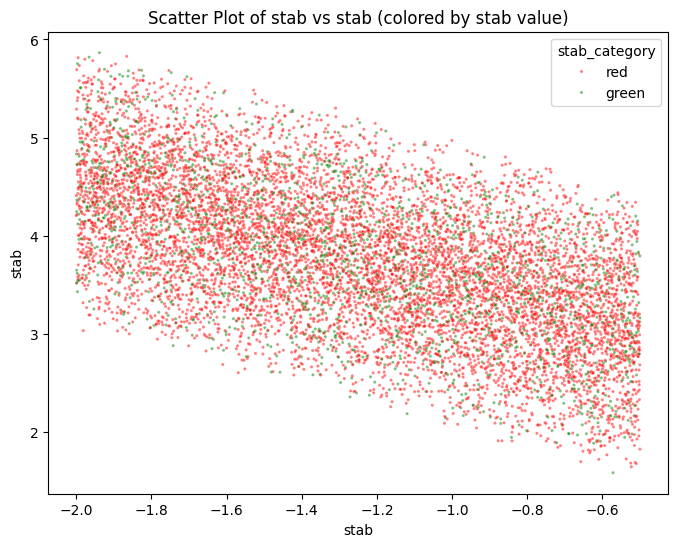

In [ ]:

data['stab_category'] = data['stab'].apply(lambda x: 'green' if x > 0.05 else 'red')

plt.figure(figsize=(8, 6))
sns.scatterplot(x=data['p3'], y=data['p1'], hue=data['stab_category'], palette={'green': 'green', 'red': 'red'}, alpha=0.5, s=5)
plt.title('Scatter Plot of stab vs stab (colored by stab value)')
plt.xlabel('stab')
plt.ylabel('stab')

plt.show()